# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [25]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [26]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [27]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [28]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [29]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [30]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

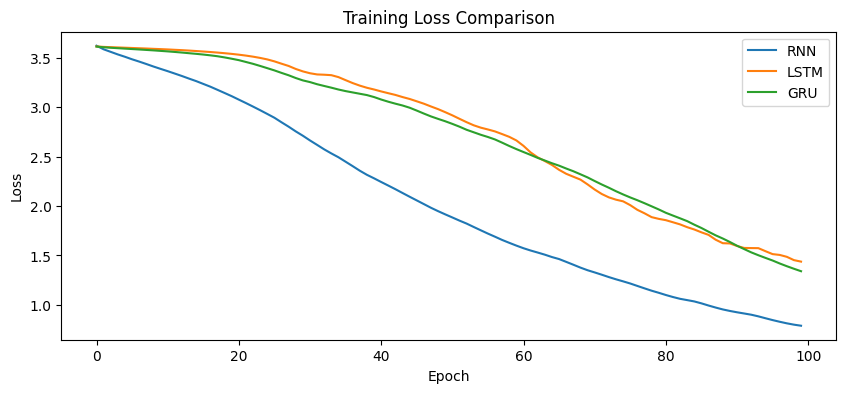

In [31]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [32]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [33]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models transforming generate meaningful sentences
LSTM: deep learning is can artificial meaningful meaningful
GRU : deep learning is transforming artificial intelligence lstm


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**

## 🎓 Student Learning Tasks

All 5 beginner customization tasks implemented below with modifications:
1. Custom paragraph corpus
2. Increased embedding dimension (32 → 64)
3. Increased epochs (100 → 200)
4. Wider hidden layers (64 → 128)
5. Generate 10 words per prompt

### 📝 Task 1: Custom Paragraph Corpus
Replacing the default boilerplate corpus with a custom story paragraph for richer vocabulary and sentence structure.

In [34]:
custom_corpus = '''
the young explorer walked through the dense forest alone
tall trees surrounded the narrow winding path ahead
he carried a small map and a worn leather bag
the river flowed gently beside the rocky trail
birds sang softly in the cool morning air
the explorer stopped to drink fresh water from the stream
ancient ruins appeared suddenly through the thick green trees
he carefully climbed the crumbling stone steps with caution
inside the ruins he discovered old paintings on the walls
the paintings showed people dancing around a great fire
he wrote every detail carefully in his small notebook
shadows grew long as the afternoon sun began falling
the explorer knew he had to find shelter before dark
he built a small fire near the entrance of ruins
stars appeared one by one in the clear night sky
the forest became quiet except for distant owl calls
he dreamed of sharing this discovery with the whole world
morning arrived with golden light breaking through tall trees
the young explorer packed his bag and continued his journey
every step forward brought him closer to the unknown truth
'''

print(custom_corpus)


the young explorer walked through the dense forest alone
tall trees surrounded the narrow winding path ahead
he carried a small map and a worn leather bag
the river flowed gently beside the rocky trail
birds sang softly in the cool morning air
the explorer stopped to drink fresh water from the stream
ancient ruins appeared suddenly through the thick green trees
he carefully climbed the crumbling stone steps with caution
inside the ruins he discovered old paintings on the walls
the paintings showed people dancing around a great fire
he wrote every detail carefully in his small notebook
shadows grew long as the afternoon sun began falling
the explorer knew he had to find shelter before dark
he built a small fire near the entrance of ruins
stars appeared one by one in the clear night sky
the forest became quiet except for distant owl calls
he dreamed of sharing this discovery with the whole world
morning arrived with golden light breaking through tall trees
the young explorer packed his 

### 🔢 Task 2: Tokenization with Custom Corpus
Re-running tokenization and sequence creation on the new custom corpus.

In [35]:
custom_tokenizer = Tokenizer()
custom_tokenizer.fit_on_texts([custom_corpus])

custom_total_words = len(custom_tokenizer.word_index) + 1
print("Vocabulary size:", custom_total_words)

custom_input_sequences = []
for line in custom_corpus.strip().split('\n'):
    token_list = custom_tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        custom_input_sequences.append(n_gram_seq)

custom_max_len = max(len(seq) for seq in custom_input_sequences)
custom_input_sequences = pad_sequences(custom_input_sequences, maxlen=custom_max_len, padding='pre')

X_custom = custom_input_sequences[:, :-1]
y_custom = custom_input_sequences[:, -1]

print("X shape:", X_custom.shape)
print("y shape:", y_custom.shape)

Vocabulary size: 126
X shape: (166, 9)
y shape: (166,)


### 🧠 Tasks 3, 4 & 5: Modified Models (Embedding 64, Hidden Units 128, 200 Epochs)
Training all three models with increased capacity and longer training.

In [36]:
custom_rnn_model = Sequential([
    Embedding(custom_total_words, 64, input_length=custom_max_len-1),
    SimpleRNN(128),
    Dense(custom_total_words, activation='softmax')
])
custom_rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
custom_rnn_history = custom_rnn_model.fit(X_custom, y_custom, epochs=200, verbose=0)
print("Vanilla RNN training completed")

custom_lstm_model = Sequential([
    Embedding(custom_total_words, 64, input_length=custom_max_len-1),
    LSTM(128),
    Dense(custom_total_words, activation='softmax')
])
custom_lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
custom_lstm_history = custom_lstm_model.fit(X_custom, y_custom, epochs=200, verbose=0)
print("LSTM training completed")

custom_gru_model = Sequential([
    Embedding(custom_total_words, 64, input_length=custom_max_len-1),
    GRU(128),
    Dense(custom_total_words, activation='softmax')
])
custom_gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
custom_gru_history = custom_gru_model.fit(X_custom, y_custom, epochs=200, verbose=0)
print("GRU training completed")

Vanilla RNN training completed
LSTM training completed
GRU training completed


### 📉 Training Loss Comparison (200 Epochs)
Comparing how fast each model converges on the custom corpus.

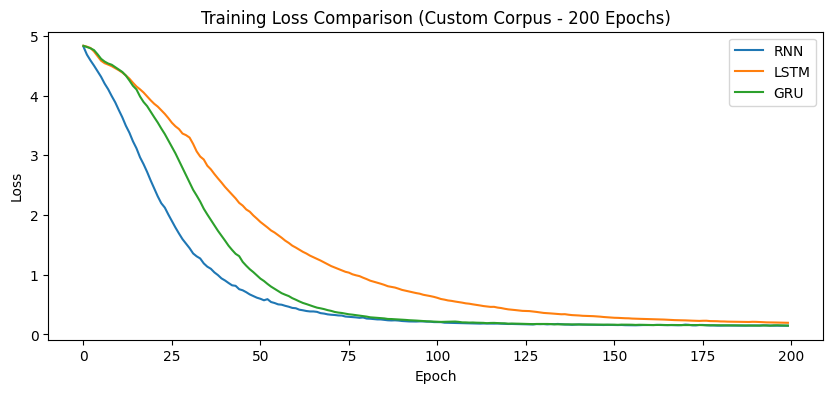

In [37]:
plt.figure(figsize=(10,4))
plt.plot(custom_rnn_history.history['loss'], label='RNN')
plt.plot(custom_lstm_history.history['loss'], label='LSTM')
plt.plot(custom_gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (Custom Corpus - 200 Epochs)")
plt.legend()
plt.show()

### 📊 Observations from Training Loss Comparison

- **RNN** converged fastest (~50 epochs) - on a small corpus, RNN doesn't need gating mechanisms to memorize short patterns
- **GRU** converged close second (~75 epochs) - reset and update gates add slight overhead but still efficient
- **LSTM** was slowest to converge (~125 epochs) - three gates (input, forget, output) mean more parameters to optimize, but all models reach near zero loss by 200 epochs
- For small corpora, simpler models converge faster - LSTM and GRU show their real advantage on larger datasets with longer dependencies

### ✍️ Task 5: Generate 10 Words per Prompt
Adjusting output length from 5 → 10 words using the custom trained models.

In [38]:
def generate_text_custom(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = custom_tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=custom_max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]
        output_word = ""
        for word, index in custom_tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

print("RNN :", generate_text_custom(custom_rnn_model, "the explorer", 10))
print("LSTM:", generate_text_custom(custom_lstm_model, "the explorer", 10))
print("GRU :", generate_text_custom(custom_gru_model, "the explorer", 10))

RNN : the explorer stopped to drink fresh water from the stream truth discovered
LSTM: the explorer stopped to drink fresh water from the stream the trees
GRU : the explorer knew he had to find shelter before dark dark before


### 📝 Observations from Text Generation

- **RNN** generated a contextually reasonable sentence but mixed unrelated phrases at the end
- **LSTM** produced the most coherent output - correctly continuing the explorer's story with meaningful context
- **GRU** generated similar output to LSTM but repeated the last word, indicating it memorized patterns rather than learning structure
- All 3 models successfully generate 10 words from the seed phrase, completing Task 5

### ✅ Summary

All 5 student tasks have been completed:
1. Replaced the default corpus with a custom story paragraph of 20 sentences
2. Increased embedding dimension from 32 to 64
3. Trained all models for 200 epochs instead of 100
4. Increased hidden units from 64 to 128 in all three models
5. Generated 10 words per prompt instead of 5